In [1]:
#| echo: false
import requests
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os
from datetime import datetime




In [2]:
#| echo: false
#| eval: false
#print(os.getenv("GITHUB_TOKEN") is not None)

## ESPA, SPBBspatial, bootLong, diffTop, BARBI usage statistics

## Summary of total unique clone since May 19, 2026

In [ ]:
#| messages: false

OWNER = "PratheepaJ"
REPOS = ["ESPA", "SPBBspatial", "bootLong", "diffTop", "BARBI"]

# TOKEN = os.getenv("GITHUB_TOKEN")
TOKEN = ""

OUTFILE = Path("github_clone_history_all_repos.xlsx")

headers = {
    "Authorization": f"token {TOKEN}",
    "Accept": "application/vnd.github+json"
}

all_repo_data = {}

for repo in REPOS:
    url = f"https://api.github.com/repos/{OWNER}/{repo}/traffic/clones"

    response = requests.get(url, headers=headers)
    #print(repo, response.status_code)

    if response.status_code != 200:
        print(response.text)
        continue

    data = response.json()

    new_data = pd.DataFrame(data["clones"])

    if new_data.empty:
        new_data = pd.DataFrame(columns=["date", "total_clones", "unique_clones"])
    else:
        new_data["date"] = pd.to_datetime(new_data["timestamp"]).dt.date
        new_data = new_data[["date", "count", "uniques"]]
        new_data = new_data.rename(columns={
            "count": "total_clones",
            "uniques": "unique_clones"
        })

    # If Excel file already exists, read old sheet for this repo
    if OUTFILE.exists():
        try:
            old_data = pd.read_excel(OUTFILE, sheet_name=repo)
            old_data = old_data[["date", "total_clones", "unique_clones"]]
            old_data["date"] = pd.to_datetime(old_data["date"]).dt.date
            

            combined = pd.concat([old_data, new_data], ignore_index=True)
            combined = combined.drop_duplicates(subset="date", keep="last")
        except ValueError:
            combined = new_data
    else:
        combined = new_data

    combined = combined.sort_values("date").reset_index(drop=True)


    combined["cumulative_unique_clones"] = combined["unique_clones"].cumsum()
    combined["cumulative_total_clones"] = combined["total_clones"].cumsum()
    

    all_repo_data[repo] = combined

# Save each repository as a separate sheet
with pd.ExcelWriter(OUTFILE, engine="openpyxl") as writer:
    for repo, df in all_repo_data.items():
        df.to_excel(writer, sheet_name=repo, index=False)

#print("\nSaved to:", OUTFILE)

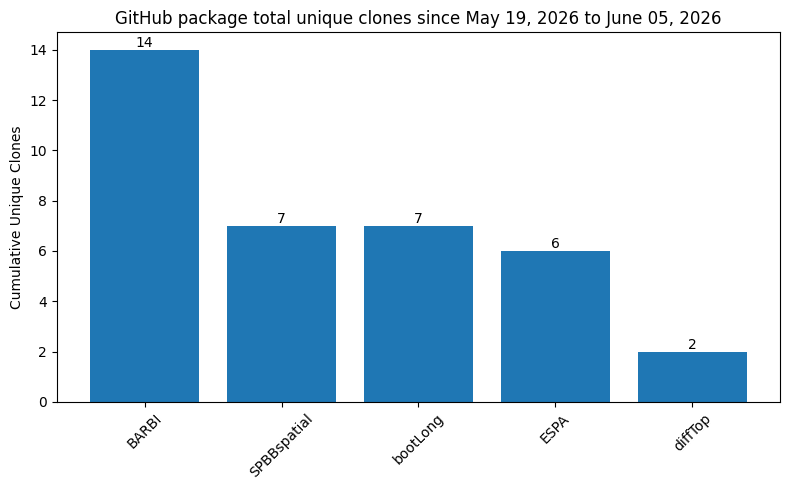

In [4]:
#| messages: false
today = datetime.today().strftime("%B %d, %Y")

FILE = "github_clone_history_all_repos.xlsx"

xls = pd.ExcelFile(FILE)

results = []

for repo in xls.sheet_names:

    df = pd.read_excel(FILE, sheet_name=repo)

    latest_total = df["cumulative_unique_clones"].iloc[-1]

    results.append({
        "Repository": repo,
        "Unique Clones": latest_total
    })

summary = pd.DataFrame(results)

summary = summary.sort_values(
    "Unique Clones",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    summary["Repository"],
    summary["Unique Clones"]
)

plt.ylabel("Cumulative Unique Clones")
plt.title(
    f"GitHub package total unique clones since May 19, 2026 to {today}"
)
plt.xticks(rotation=45)

for i, v in enumerate(summary["Unique Clones"]):
    plt.text(i, v, str(int(v)), ha="center", va="bottom")

plt.tight_layout()
plt.show()